<a href="https://colab.research.google.com/github/KevinParker02/Colab-M.L-/blob/EDA_FundamentosML_KevinVivanco/EDA_FundamentosML_KevinVivanco_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importación de librerías

In [2]:
# Tratamiento de datos
import pandas as pd
import numpy as np
from scipy import stats

# Gráficos
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Preprocesado y modelado
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# Configuración matplotlib (Visualizaciones)
plt.style.use('ggplot')
sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')

# Carga del DataSet

In [13]:
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
    name=fn
df = pd.read_csv(name, sep=",")

print("Primeras 5 filas del dataset:")
pd.set_option('display.max_columns', None)
df.head()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition (1).csv
Primeras 5 filas del dataset:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


# 1. Exploración de los datos

In [4]:
# Información general del dataset
print("\nInformación general del dataset:")
df.info()


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   in

In [ ]:
# Descripción estadística básica
print("\nEstadísticas descriptivas básicas:")
df.describe()


Estadísticas descriptivas básicas:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
# Analizar valores nulos
print("\nCantidad de valores nulos por columna:")
df.isnull().sum()


Cantidad de valores nulos por columna:


,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


# 1.1 Identificación y clasificación de varibles

In [ ]:
print("\n--- Clasificación de variables ---")

# Variables numéricas
numericas_continuas = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
    'MonthlyRate', 'PercentSalaryHike', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

numericas_discretas = [
    'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'JobInvolvement',
    'JobLevel', 'JobSatisfaction', 'NumCompaniesWorked', 'PerformanceRating',
    'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'WorkLifeBalance'
]

# Variables categóricas
categoricas_nominales = [
    'Attrition', 'BusinessTravel', 'Department', 'EducationField',
    'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime'
]

categoricas_ordinales = ['Education']

print("Variables numéricas continuas:", numericas_continuas)
print("Variables numéricas discretas:", numericas_discretas)
print("Variables categóricas nominales:", categoricas_nominales)
print("Variables categóricas ordinales:", categoricas_ordinales)


# Convertir variables categóricas
for col in categoricas_nominales + categoricas_ordinales:
    df[col] = df[col].astype('category')


--- Clasificación de variables ---
Variables numéricas continuas: ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Variables numéricas discretas: ['EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'NumCompaniesWorked', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'WorkLifeBalance']
Variables categóricas nominales: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']
Variables categóricas ordinales: ['Education']


# 2 Medidas de tendencia central y dispersión para variables numéricas

2.1 Variables nominales

In [ ]:
# Estadísticas básicas con percentiles personalizados
print("\n--- Estadísticas descriptivas para variables numéricas ---")
stats_df = df[numericas_continuas].describe(percentiles=[0.25, 0.5, 0.75])
stats_df = stats_df.T
stats_df['cv'] = stats_df['std'] / stats_df['mean']
stats_df['skew'] = df[numericas_continuas].skew()
stats_df['kurt'] = df[numericas_continuas].kurtosis()
stats_df = stats_df.round(2)
print(stats_df)


--- Estadísticas descriptivas para variables numéricas ---
                          count      mean      std     min     25%      50%  \
Age                      1470.0     36.92     9.14    18.0    30.0     36.0   
DailyRate                1470.0    802.49   403.51   102.0   465.0    802.0   
DistanceFromHome         1470.0      9.19     8.11     1.0     2.0      7.0   
HourlyRate               1470.0     65.89    20.33    30.0    48.0     66.0   
MonthlyIncome            1470.0   6502.93  4707.96  1009.0  2911.0   4919.0   
MonthlyRate              1470.0  14313.10  7117.79  2094.0  8047.0  14235.5   
PercentSalaryHike        1470.0     15.21     3.66    11.0    12.0     14.0   
TotalWorkingYears        1470.0     11.28     7.78     0.0     6.0     10.0   
TrainingTimesLastYear    1470.0      2.80     1.29     0.0     2.0      3.0   
YearsAtCompany           1470.0      7.01     6.13     0.0     3.0      5.0   
YearsInCurrentRole       1470.0      4.23     3.62     0.0     2.0     

In [ ]:
# Función para calcular la moda (adaptada a nuevas versiones de scipy)
def get_mode(x):
    mode_result = stats.mode(x, keepdims=True)  # keepdims es necesario para evitar warnings en scipy >= 1.9
    return mode_result.mode[0]

print("\n--- Moda para variables numéricas ---")
modes = {col: get_mode(df[col]) for col in numericas_continuas}
for col, mode_val in modes.items():
    print(f"{col}: {mode_val}")


--- Moda para variables numéricas ---
Age: 35
DailyRate: 691
DistanceFromHome: 2
HourlyRate: 66
MonthlyIncome: 2342
MonthlyRate: 4223
PercentSalaryHike: 11
TotalWorkingYears: 10
TrainingTimesLastYear: 2
YearsAtCompany: 5
YearsInCurrentRole: 2
YearsSinceLastPromotion: 0
YearsWithCurrManager: 2


In [ ]:
print("\n--- Análisis de distribución y sesgo ---")
for col in ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsSinceLastPromotion']:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    print(f"{col}:")
    print(f"  Asimetría (Skewness): {skew:.2f} - ", end="")
    if skew > 0.5:
        print("Sesgo positivo significativo (cola a la derecha)")
    elif skew < -0.5:
        print("Sesgo negativo significativo (cola a la izquierda)")
    else:
        print("Distribución aproximadamente simétrica")

    print(f"  Curtosis: {kurt:.2f} - ", end="")
    if kurt > 0.5:
        print("Leptocúrtica (más apuntada que la normal)")
    elif kurt < -0.5:
        print("Platicúrtica (más aplanada que la normal)")
    else:
        print("Mesocúrtica (similar a la normal)")
    print()


--- Análisis de distribución y sesgo ---
Age:
  Asimetría (Skewness): 0.41 - Distribución aproximadamente simétrica
  Curtosis: -0.40 - Mesocúrtica (similar a la normal)

MonthlyIncome:
  Asimetría (Skewness): 1.37 - Sesgo positivo significativo (cola a la derecha)
  Curtosis: 1.01 - Leptocúrtica (más apuntada que la normal)

TotalWorkingYears:
  Asimetría (Skewness): 1.12 - Sesgo positivo significativo (cola a la derecha)
  Curtosis: 0.92 - Leptocúrtica (más apuntada que la normal)

YearsSinceLastPromotion:
  Asimetría (Skewness): 1.98 - Sesgo positivo significativo (cola a la derecha)
  Curtosis: 3.61 - Leptocúrtica (más apuntada que la normal)



2.2 Variables categóricas

In [ ]:
# Frecuencias absolutas y relativas para variables categóricas
for col in categoricas_nominales + categoricas_ordinales:
    print(f"\nFrecuencias para {col}:")
    freq_abs = df[col].value_counts()
    freq_rel = df[col].value_counts(normalize=True).round(4) * 100
    freq_table = pd.DataFrame({
        'Frecuencia': freq_abs,
        'Porcentaje (%)': freq_rel
    })
    print(freq_table)
    print(f"Moda: {freq_abs.index[0]} (aparece {freq_abs.iloc[0]} veces)")


Frecuencias para Attrition:
           Frecuencia  Porcentaje (%)
Attrition                            
No               1233           83.88
Yes               237           16.12
Moda: No (aparece 1233 veces)

Frecuencias para BusinessTravel:
                   Frecuencia  Porcentaje (%)
BusinessTravel                               
Travel_Rarely            1043           70.95
Travel_Frequently         277           18.84
Non-Travel                150           10.20
Moda: Travel_Rarely (aparece 1043 veces)

Frecuencias para Department:
                        Frecuencia  Porcentaje (%)
Department                                        
Research & Development         961           65.37
Sales                          446           30.34
Human Resources                 63            4.29
Moda: Research & Development (aparece 961 veces)

Frecuencias para EducationField:
                  Frecuencia  Porcentaje (%)
EducationField                              
Life Sciences            6

In [ ]:
print("\n--- Relación entre categóricas y Attrition ---")
for col in categoricas_nominales + categoricas_ordinales:
    if col != 'Attrition':  # Evitar comparar consigo misma
        print(f"\n{col} vs Attrition:")
        cross_tab = pd.crosstab(df[col], df['Attrition'], normalize='index') * 100
        print(round(cross_tab, 2))


# 3 Gráficas para el análisis


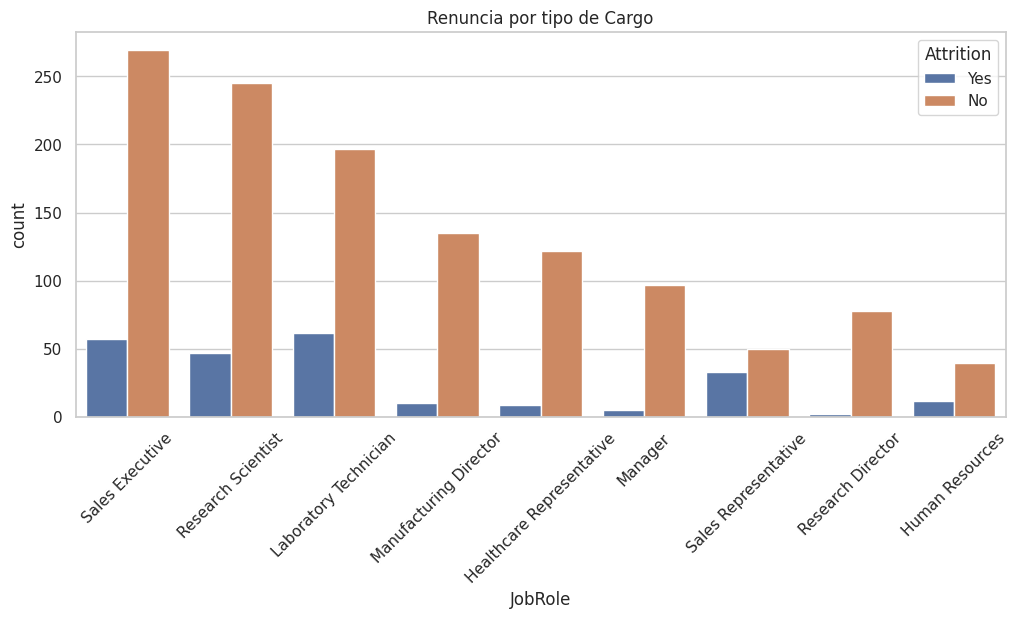

In [8]:
# Countplot de JobRole con hue=Attrition
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='JobRole', hue='Attrition')
plt.xticks(rotation=45)
plt.title('Renuncia por tipo de Cargo')
plt.show()

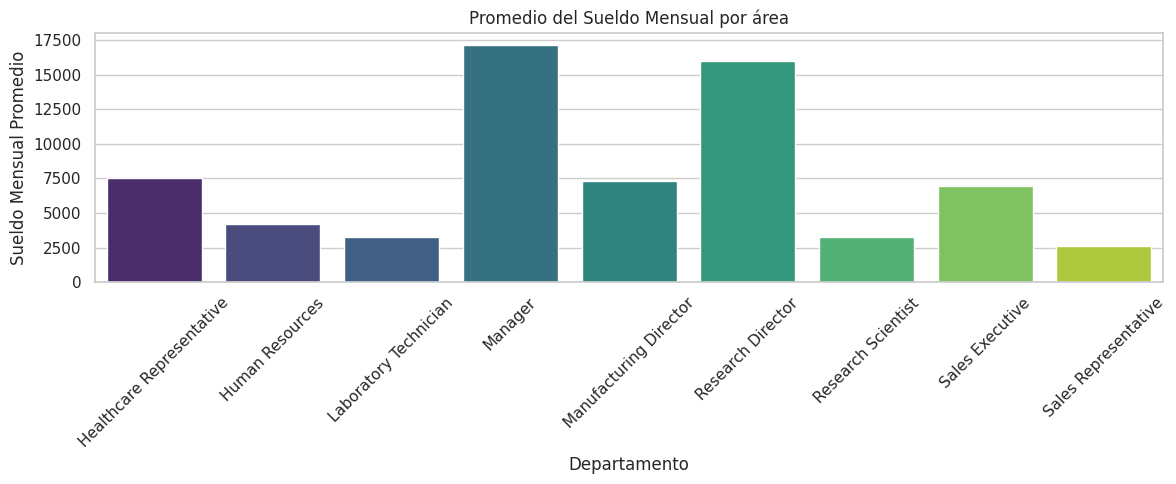

In [24]:

average_salary_by_department = df.groupby('JobRole')['MonthlyIncome'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=average_salary_by_department, x='JobRole', y='MonthlyIncome', palette='viridis')
plt.xticks(rotation=45)
plt.title('Promedio del Sueldo Mensual por área')
plt.xlabel('Departamento')
plt.ylabel('Sueldo Mensual Promedio')
plt.tight_layout()
plt.show()


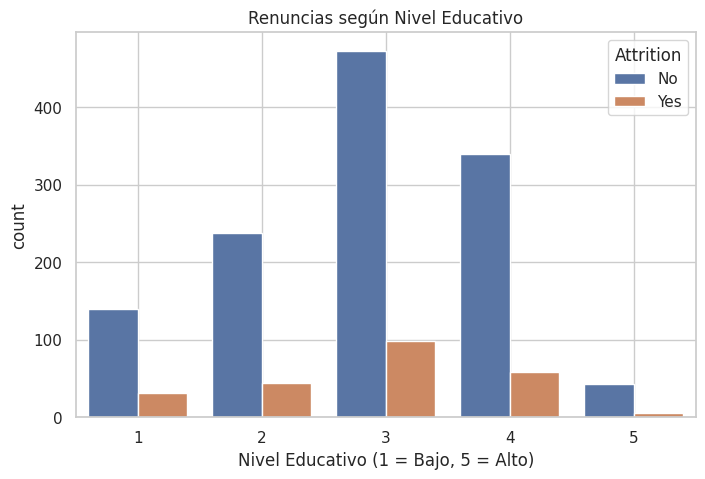

In [9]:
edu_order = [1, 2, 3, 4, 5]
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Education', order=edu_order, hue='Attrition')
plt.title('Renuncias según Nivel Educativo')
plt.xlabel('Nivel Educativo (1 = Bajo, 5 = Alto)')
plt.grid(True)
plt.savefig('educacion_vs_attrition.png')
plt.show()


3.2 Análisis de correlación y relaciones entre variables

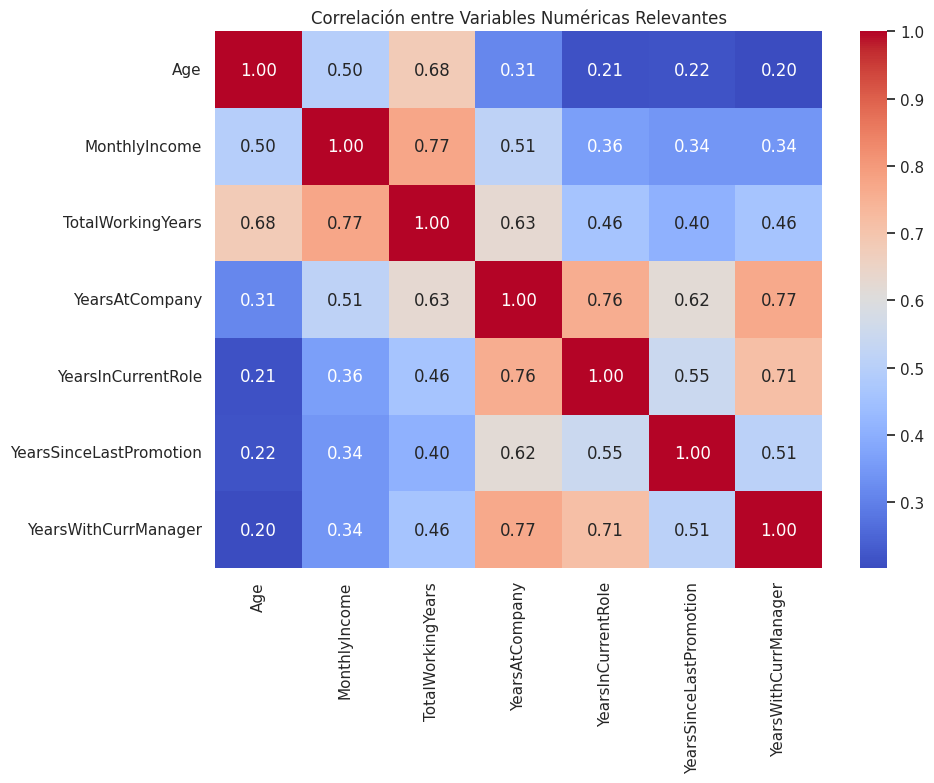

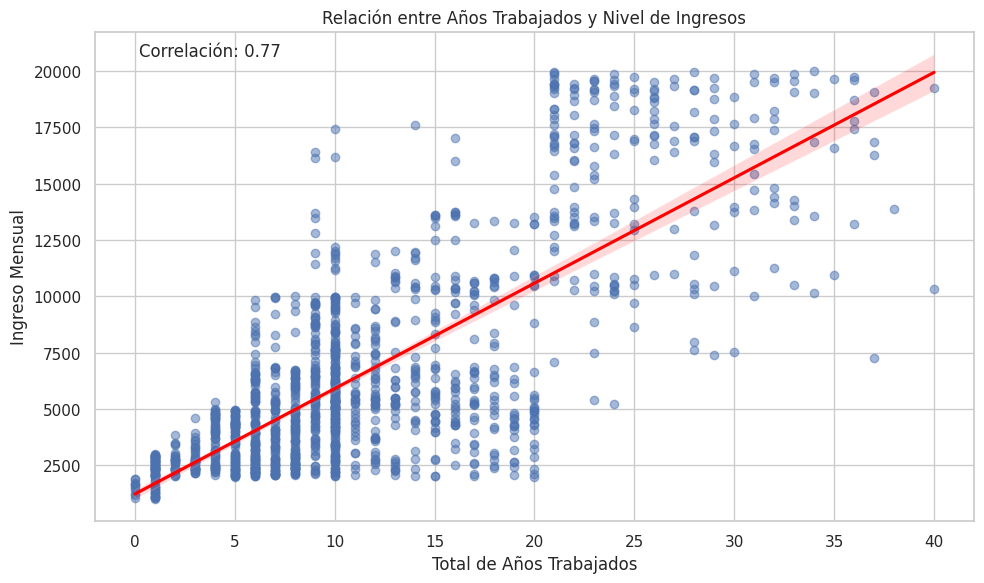

In [34]:
numeric_corr_vars = [
    'Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_corr_vars].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación entre Variables Numéricas Relevantes')
plt.tight_layout()
plt.savefig('correlacion_variables_empleados.png')
plt.show()

# gráfica de dispersión con línea de regresión
plt.figure(figsize=(10, 6))
sns.regplot(x='TotalWorkingYears', y='MonthlyIncome', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relación entre Años Trabajados y Nivel de Ingresos')
plt.xlabel('Total de Años Trabajados')
plt.ylabel('Ingreso Mensual')
corr = df['TotalWorkingYears'].corr(df['MonthlyIncome'])
plt.annotate(f'Correlación: {corr:.2f}', xy=(0.05, 0.95), xycoords='axes fraction')
plt.tight_layout()
plt.savefig('relacion_antiguedad_ingresos.png')
plt.show()

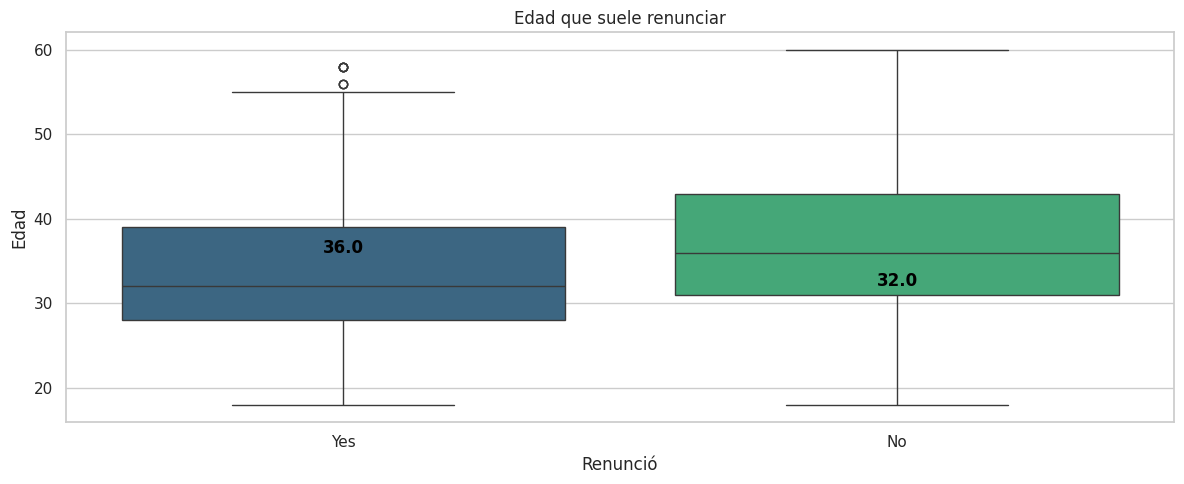

In [28]:
# Crear el diagrama de caja para la edad según si renunció o no
plt.figure(figsize=(12, 5))
boxplot = sns.boxplot(data=df, x='Attrition', y='Age', palette='viridis')

# Agregar etiquetas con los valores exactos de la mediana
medians = df.groupby(['Attrition'])['Age'].median().values
for xtick in boxplot.get_xticks(): boxplot.text(xtick, medians[xtick], round(medians[xtick], 2), horizontalalignment='center', size='medium', color='black', weight='semibold')

plt.title('Edad que suele renunciar')
plt.xlabel('Renunció')
plt.ylabel('Edad')
plt.tight_layout()

# Mostrar la gráfica
plt.show()



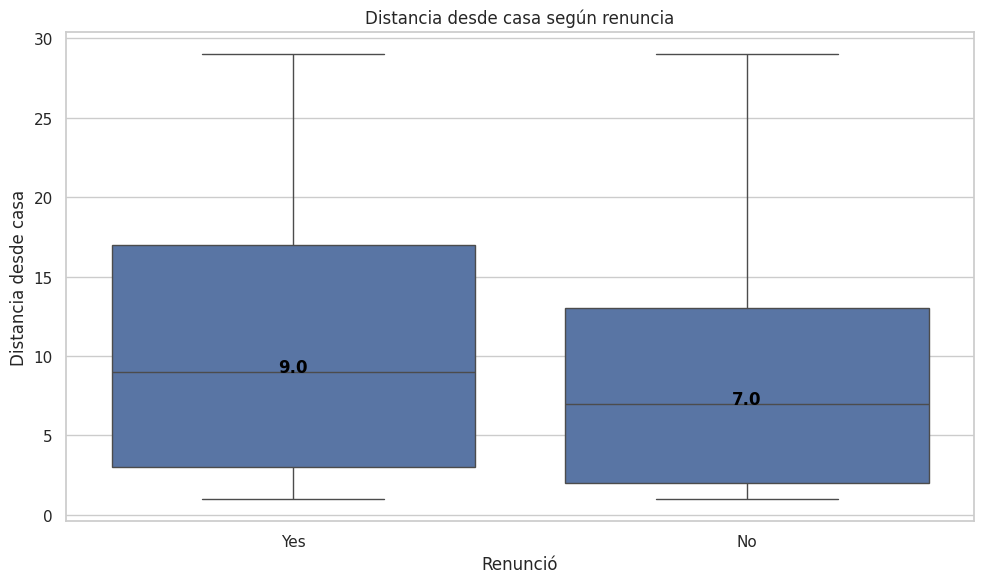

Mediana de la distancia desde casa para empleados que renuncian: 9.0
Mediana de la distancia desde casa para empleados que no renuncian: 7.0
Promedio de la distancia desde casa para empleados que renuncian: 10.632911392405063
Promedio de la distancia desde casa para empleados que no renuncian: 8.915652879156529
Distancia mínima desde casa: 1
Distancia máxima desde casa: 29


In [36]:
# Calcular la mediana de la distancia desde casa para los empleados que renuncian y los que no renuncian
median_distance_yes = df[df['Attrition'] == 'Yes']['DistanceFromHome'].median()
median_distance_no = df[df['Attrition'] == 'No']['DistanceFromHome'].median()

# Calcular el promedio de la distancia desde casa para los empleados que renuncian y los que no renuncian
mean_distance_yes = df[df['Attrition'] == 'Yes']['DistanceFromHome'].mean()
mean_distance_no = df[df['Attrition'] == 'No']['DistanceFromHome'].mean()

# Mínimos y máximos
min_distance = df['DistanceFromHome'].min()
max_distance = df['DistanceFromHome'].max()

# Crear el diagrama de caja para la distancia desde casa según si renunció o no
plt.figure(figsize=(10, 6))
boxplot = sns.boxplot(x='Attrition', y='DistanceFromHome', data=df)

# Agregar etiquetas con los valores exactos de la mediana (CORREGIDO)
medians = df.groupby('Attrition')['DistanceFromHome'].median().to_dict()
for xtick in boxplot.get_xticks():
    label = boxplot.get_xticklabels()[xtick].get_text()  # 'Yes' o 'No'
    median_val = medians[label]
    boxplot.text(xtick, median_val, round(median_val, 2),
                 horizontalalignment='center', size='medium', color='black', weight='semibold')

plt.title('Distancia desde casa según renuncia')
plt.xlabel('Renunció')
plt.ylabel('Distancia desde casa')
plt.tight_layout()
plt.show()

# Mostrar los valores en consola
print(f"Mediana de la distancia desde casa para empleados que renuncian: {median_distance_yes}")
print(f"Mediana de la distancia desde casa para empleados que no renuncian: {median_distance_no}")
print(f"Promedio de la distancia desde casa para empleados que renuncian: {mean_distance_yes}")
print(f"Promedio de la distancia desde casa para empleados que no renuncian: {mean_distance_no}")
print(f"Distancia mínima desde casa: {min_distance}")
print(f"Distancia máxima desde casa: {max_distance}")



# Conclusiones

Base al análisis de las correlaiones y variables más relevantes que justifican la renuncia de los empleados son las siguientes:

1.- Renuncia por tipo de cargo, se pudo rescatar que las áreas donde se presenta un alza en las renuncias por parte de los empleados es en Laboratory Technician y Sales Exceutive, el primero se puede justificar porque su promedio de salario mensual es bajo a diferencia de Sales Exceutive que gana mucho más alto que el promedio del sueldo mensual (4919 dólares)

2.- Según el nivel educativo se intuye que la mayor participación laboral de la empresa corresponde a empleados con nivel de estudio 3, que también correponde a la mayor tasa de desempleo a diferencia de los otros niveles de estudio que puede ignificar que a contar con cierta preparación académica, las condiciones laborales o las oportunidades de crecimiento no satisfacen sus expectativas.

3.- La relación entre años de trabajo y niveles de ingreso es altamente positiva (0,77), es decir ue a medida que aumentan sus años dentro de la empresa aumenta su sueldo. Pero asimismo se presencia ingresos relativamente bajos en comparación con lo esperado según el promedio, esto puede deverse al área en cual se dempeñe el empleado.

4.- A través de un gráfico de cajas, se identificó que la edad promedio de renuncia es de 36 años, ligeramente mayor que la de quienes permanecen en la empresa. Además, la distancia desde el hogar al trabajo es un factor importante: los empleados que renuncian viven, en promedio, más lejos (mediana de 9 km) que aquellos que no lo hacen (mediana de 7 km), lo que puede implicar un mayor desgaste físico y emocional.